# Roadside Assistance Chatbot
A conversational triage assistant for roadside assistance dispatch. Collects structured information from stranded motorists and routes to the appropriate service using a rule engine and a Random Forest classifier, backed by a SQLite database and served via Gradio.


In [1]:
!pip install -q gradio pandas scikit-learn matplotlib seaborn joblib

In [2]:
import gradio as gr
import pandas as pd
import sqlite3, uuid, random, json, joblib, time
from datetime import datetime
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


In [3]:
DB_PATH = "roadside_assistance.db"

def get_conn():
    return sqlite3.connect(DB_PATH, check_same_thread=False)

def init_db():
    conn = get_conn()
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS sessions (
        session_id TEXT PRIMARY KEY,
        started_at TEXT, current_step TEXT, complete INTEGER DEFAULT 0
    )""")
    cur.execute("""
    CREATE TABLE IF NOT EXISTS answers (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        session_id TEXT, field_name TEXT, field_value TEXT, created_at TEXT
    )""")
    cur.execute("""
    CREATE TABLE IF NOT EXISTS events (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        session_id TEXT, speaker TEXT, message TEXT,
        field_name TEXT, field_value TEXT, created_at TEXT
    )""")
    cur.execute("""
    CREATE TABLE IF NOT EXISTS outcomes (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        session_id TEXT, recommendation TEXT,
        ml_prediction TEXT, ml_confidence REAL, summary TEXT, created_at TEXT
    )""")
    cur.execute("""
    CREATE TABLE IF NOT EXISTS agent_queue (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        session_id TEXT, priority TEXT, status TEXT,
        summary TEXT, recommendation TEXT,
        ml_prediction TEXT, ml_confidence REAL, debug_json TEXT, created_at TEXT
    )""")
    conn.commit()
    conn.close()

init_db()
print("SQLite initialised:", DB_PATH)

SQLite initialised: roadside_assistance.db


## Workflow Definition


In [4]:
WORKFLOWS = {
    "start":              {"message": "Hi! What seems to be the issue?",                                 "response_type": "radio",  "field": "issue_type",          "options": ["Flat tire","Battery / won't start","Locked out","Need towing","Other"]},
    "safe_location":      {"message": "Are you currently in a safe location away from traffic?",    "response_type": "radio",  "field": "safe_location",       "options": ["Yes","No"]},
    "flat_tire_all_tires_ok": {"message": "Are all the other tires OK?",                            "response_type": "radio",  "field": "all_tires_ok",        "options": ["Yes","No"]},
    "flat_tire_has_spare":{"message": "Do you have a spare tire available?",                        "response_type": "radio",  "field": "has_spare",           "options": ["Yes","No"]},
    "vehicle_drivable":   {"message": "Is the vehicle currently drivable?",                         "response_type": "radio",  "field": "vehicle_drivable",    "options": ["Yes","No"]},
    "dashboard_lights_on":{"message": "Do dashboard lights come on when you try to start?",         "response_type": "radio",  "field": "dashboard_lights_on", "options": ["Yes","No"]},
    "locked_keys_inside": {"message": "Are the keys locked inside the vehicle?",                    "response_type": "radio",  "field": "locked_keys_inside",  "options": ["Yes","No"]},
    "other_description":  {"message": "Please briefly describe the issue.",                          "response_type": "text",   "field": "other_description"},
    "location_text":      {"message": "Please type your location or a nearby landmark.",             "response_type": "text",   "field": "location_text"},
}
print("Workflows loaded:", list(WORKFLOWS.keys()))

Workflows loaded: ['start', 'safe_location', 'flat_tire_all_tires_ok', 'flat_tire_has_spare', 'vehicle_drivable', 'dashboard_lights_on', 'locked_keys_inside', 'other_description', 'location_text']


## Data Generation


In [5]:
def generate_fake_case():
    issue_type          = random.choice(["flat_tire","battery","lockout","towing","other"])
    safe_location       = random.choices(["Yes","No"], weights=[90, 10])[0]
    vehicle_drivable    = random.choice(["Yes","No"])
    all_tires_ok        = random.choice(["Yes","No"])
    has_spare           = random.choice(["Yes","No"])
    dashboard_lights_on = random.choice(["Yes","No"])
    locked_keys_inside  = random.choice(["Yes","No"])

    if safe_location == "No":
        service = "human_escalation"
    elif issue_type == "flat_tire":
        if has_spare == "Yes":
            service = "tire_change"
        else:
            service = "mobile_tire_support" if vehicle_drivable == "Yes" else "towing"
    elif issue_type == "battery":
        service = "jump_start" if dashboard_lights_on == "Yes" else "diagnostic_or_tow"
    elif issue_type == "lockout":
        service = "locksmith" if locked_keys_inside == "Yes" else "human_escalation"
    elif issue_type == "towing":
        service = "towing"
    else:
        service = "human_escalation"

    return {
        "issue_type": issue_type, "safe_location": safe_location,
        "vehicle_drivable": vehicle_drivable, "all_tires_ok": all_tires_ok,
        "has_spare": has_spare, "dashboard_lights_on": dashboard_lights_on,
        "locked_keys_inside": locked_keys_inside, "service_type": service
    }


def generate_balanced_dataset(n=2000):
    """Generate a balanced training corpus with exactly n//7 rows per class."""
    ISSUE_TYPES = ["flat_tire", "battery", "lockout", "towing", "other"]

    SAFE_TEMPLATES = {
        "tire_change":         {"issue_type":"flat_tire",  "safe_location":"Yes", "has_spare":"Yes",  "vehicle_drivable":"Yes", "dashboard_lights_on":"No",  "locked_keys_inside":"No"},
        "mobile_tire_support": {"issue_type":"flat_tire",  "safe_location":"Yes", "has_spare":"No",   "vehicle_drivable":"Yes", "dashboard_lights_on":"No",  "locked_keys_inside":"No"},
        "towing":              {"issue_type":"flat_tire",  "safe_location":"Yes", "has_spare":"No",   "vehicle_drivable":"No",  "dashboard_lights_on":"No",  "locked_keys_inside":"No"},
        "jump_start":          {"issue_type":"battery",    "safe_location":"Yes", "has_spare":"No",   "vehicle_drivable":"No",  "dashboard_lights_on":"Yes", "locked_keys_inside":"No"},
        "diagnostic_or_tow":   {"issue_type":"battery",    "safe_location":"Yes", "has_spare":"No",   "vehicle_drivable":"No",  "dashboard_lights_on":"No",  "locked_keys_inside":"No"},
        "locksmith":           {"issue_type":"lockout",    "safe_location":"Yes", "has_spare":"No",   "vehicle_drivable":"No",  "dashboard_lights_on":"No",  "locked_keys_inside":"Yes"},
    }

    per_class = n // 7
    rows = []

    for service, template in SAFE_TEMPLATES.items():
        for _ in range(per_class):
            row = template.copy()
            row["all_tires_ok"] = random.choice(["Yes", "No"])
            row["service_type"] = service
            rows.append(row)

    for i in range(per_class):
        rows.append({
            "issue_type":          ISSUE_TYPES[i % len(ISSUE_TYPES)],
            "safe_location":       "No",
            "vehicle_drivable":    random.choice(["Yes", "No"]),
            "all_tires_ok":        random.choice(["Yes", "No"]),
            "has_spare":           random.choice(["Yes", "No"]),
            "dashboard_lights_on": random.choice(["Yes", "No"]),
            "locked_keys_inside":  random.choice(["Yes", "No"]),
            "service_type":        "human_escalation",
        })

    random.shuffle(rows)
    return pd.DataFrame(rows)


sample = generate_balanced_dataset(n=2000)
print("Class distribution (counts):")
print(sample["service_type"].value_counts().to_string())
print()
print("issue_type distribution inside human_escalation rows:")
print(sample[sample["service_type"]=="human_escalation"]["issue_type"].value_counts().to_string())


Class distribution (counts):
service_type
mobile_tire_support    285
locksmith              285
human_escalation       285
towing                 285
tire_change            285
diagnostic_or_tow      285
jump_start             285

issue_type distribution inside human_escalation rows:
issue_type
lockout      57
other        57
flat_tire    57
battery      57
towing       57





## Model Training


In [6]:
FEATURE_COLS = [
    "issue_type","safe_location","vehicle_drivable",
    "all_tires_ok","has_spare","dashboard_lights_on","locked_keys_inside"
]
TARGET_COL = "service_type"

fake_data = generate_balanced_dataset(n=2000)

X = fake_data[FEATURE_COLS]
y = fake_data[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set class distribution:")
print(pd.Series(y_train).value_counts().to_string())
print()
print("Test set class distribution:")
print(pd.Series(y_test).value_counts().to_string())
print()

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_COLS)]
)

ml_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

t0 = time.time()
ml_model.fit(X_train, y_train)
train_time = time.time() - t0

preds = ml_model.predict(X_test)
acc = accuracy_score(y_test, preds)

run_log = {
    "timestamp":      datetime.now().isoformat(),
    "n_train":        len(X_train),
    "n_test":         len(X_test),
    "n_estimators":   200,
    "class_weight":   "balanced",
    "data_generator": "generate_balanced_dataset",
    "accuracy":       round(acc, 4),
    "train_time_sec": round(train_time, 3)
}
print("=== Run Log ===")
for k,v in run_log.items(): print(f"  {k}: {v}")
print()
print(classification_report(y_test, preds))


Training set class distribution:
service_type
jump_start             228
mobile_tire_support    228
human_escalation       228
tire_change            228
diagnostic_or_tow      228
locksmith              228
towing                 228

Test set class distribution:
service_type
mobile_tire_support    57
diagnostic_or_tow      57
jump_start             57
locksmith              57
towing                 57
tire_change            57
human_escalation       57

=== Run Log ===
  timestamp: 2026-03-13T07:37:02.447214
  n_train: 1596
  n_test: 399
  n_estimators: 200
  class_weight: balanced
  data_generator: generate_balanced_dataset
  accuracy: 1.0
  train_time_sec: 0.644

                     precision    recall  f1-score   support

  diagnostic_or_tow       1.00      1.00      1.00        57
   human_escalation       1.00      1.00      1.00        57
         jump_start       1.00      1.00      1.00        57
          locksmith       1.00      1.00      1.00        57
mobile_tire_suppo

## Model Persistence


In [7]:
MODEL_PATH = "roadside_model.joblib"
joblib.dump(ml_model, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}  ({Path(MODEL_PATH).stat().st_size/1024:.1f} KB)")


Model saved → roadside_model.joblib  (694.6 KB)


## Evaluation — Confusion Matrix


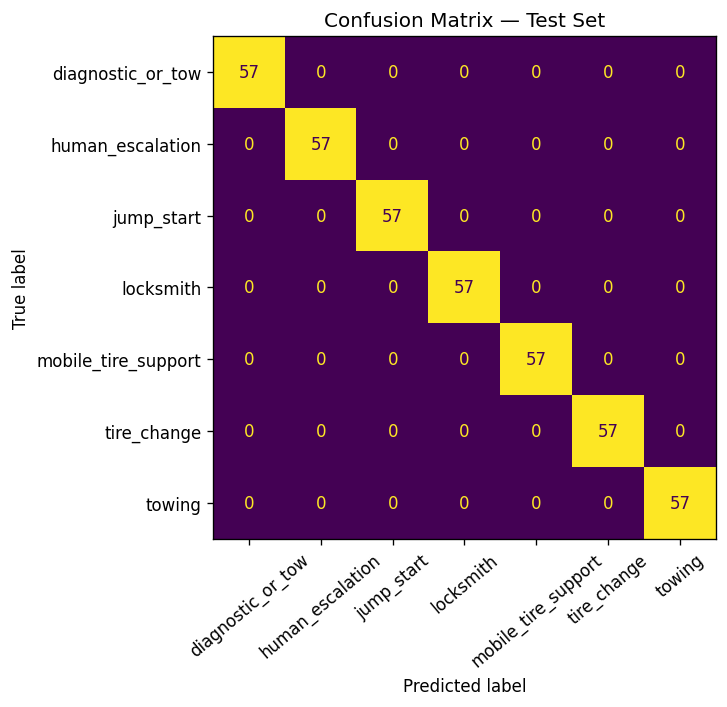


Off-diagonal errors:


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, preds, labels=ml_model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=ml_model.classes_)
disp.plot(ax=ax, xticks_rotation=40, colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("\nOff-diagonal errors:")
for i, true_label in enumerate(ml_model.classes_):
    for j, pred_label in enumerate(ml_model.classes_):
        if i != j and cm[i,j] > 0:
            print(f"  TRUE={true_label}  PREDICTED={pred_label}  count={cm[i,j]}")

## Evaluation - Cross-Validation


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ml_model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-Fold CV  F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold:  {[round(s,4) for s in cv_scores]}")
run_log["cv_f1_macro_mean"] = round(cv_scores.mean(), 4)
run_log["cv_f1_macro_std"]  = round(cv_scores.std(), 4)
print("\nFinal run log:", json.dumps(run_log, indent=2))

5-Fold CV  F1-macro: 1.0000 ± 0.0000
Per-fold:  [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

Final run log: {
  "timestamp": "2026-03-13T07:37:02.447214",
  "n_train": 1596,
  "n_test": 399,
  "n_estimators": 200,
  "class_weight": "balanced",
  "data_generator": "generate_balanced_dataset",
  "accuracy": 1.0,
  "train_time_sec": 0.644,
  "cv_f1_macro_mean": 1.0,
  "cv_f1_macro_std": 0.0
}


## Unit Tests


In [10]:
def test_generate_fake_case_keys():
    case = generate_fake_case()
    required = {"issue_type","safe_location","vehicle_drivable",
                "has_spare","dashboard_lights_on","locked_keys_inside","service_type"}
    assert required.issubset(case.keys()), f"Missing keys: {required - case.keys()}"
    print("PASS test_generate_fake_case_keys")


def test_flat_tire_no_spare_not_drivable_is_towing():
    """Verifies flat tyre, no spare, not drivable → towing."""
    row = {"issue_type":"flat_tire", "safe_location":"Yes", "vehicle_drivable":"No",
           "all_tires_ok":"Yes", "has_spare":"No",
           "dashboard_lights_on":"No", "locked_keys_inside":"No"}
    pred = ml_model.predict(pd.DataFrame([row]))[0]
    assert pred == "towing", f"Expected towing, got {pred}"
    print("PASS test_flat_tire_no_spare_not_drivable_is_towing")


def test_unsafe_location_is_human_escalation():
    """Verifies safe_location=No triggers human_escalation regardless of issue type."""
    row = {"issue_type":"flat_tire", "safe_location":"No", "vehicle_drivable":"Yes",
           "all_tires_ok":"Yes", "has_spare":"Yes",
           "dashboard_lights_on":"No", "locked_keys_inside":"No"}
    pred = ml_model.predict(pd.DataFrame([row]))[0]
    assert pred == "human_escalation", f"Expected human_escalation, got {pred}"
    print("PASS test_unsafe_location_is_human_escalation")


def test_model_predict_returns_known_class():
    row = {"issue_type":"battery", "safe_location":"Yes", "vehicle_drivable":"Yes",
           "all_tires_ok":"Yes", "has_spare":"No",
           "dashboard_lights_on":"Yes", "locked_keys_inside":"No"}
    pred = ml_model.predict(pd.DataFrame([row]))[0]
    assert pred in ml_model.classes_, f"Unknown class: {pred}"
    print("PASS test_model_predict_returns_known_class")


def test_battery_dashboard_lights_is_jump_start():
    """Verifies battery + dashboard lights on → jump_start."""
    row = {"issue_type":"battery", "safe_location":"Yes", "vehicle_drivable":"No",
           "all_tires_ok":"No", "has_spare":"No",
           "dashboard_lights_on":"Yes", "locked_keys_inside":"No"}
    pred = ml_model.predict(pd.DataFrame([row]))[0]
    assert pred == "jump_start", f"Expected jump_start, got {pred}"
    print("PASS test_battery_dashboard_lights_is_jump_start")


def test_lockout_keys_inside_is_locksmith():
    """Verifies lockout + keys confirmed inside → locksmith."""
    row = {"issue_type":"lockout", "safe_location":"Yes", "vehicle_drivable":"No",
           "all_tires_ok":"No", "has_spare":"No",
           "dashboard_lights_on":"No", "locked_keys_inside":"Yes"}
    pred = ml_model.predict(pd.DataFrame([row]))[0]
    assert pred == "locksmith", f"Expected locksmith, got {pred}"
    print("PASS test_lockout_keys_inside_is_locksmith")


test_generate_fake_case_keys()
test_flat_tire_no_spare_not_drivable_is_towing()
test_unsafe_location_is_human_escalation()
test_model_predict_returns_known_class()
test_battery_dashboard_lights_is_jump_start()
test_lockout_keys_inside_is_locksmith()
print("\nAll tests passed.")


PASS test_generate_fake_case_keys
PASS test_flat_tire_no_spare_not_drivable_is_towing
PASS test_unsafe_location_is_human_escalation
PASS test_model_predict_returns_known_class
PASS test_battery_dashboard_lights_is_jump_start
PASS test_lockout_keys_inside_is_locksmith

All tests passed.


## Core Logic — Inference, Routing, Recommendations


In [11]:
def infer_issue_type(user_text: str):
    """Infer issue type from free text. Returns (issue_type, confidence)."""
    if not user_text: return "other", 0.30
    text = user_text.lower()

    if any(k in text for k in [
        "tire", "tyre", "flat", "puncture", "wheel", "blowout"
    ]): return "flat_tire", 0.95

    if any(k in text for k in [
        "battery", "won't start", "wont start", "will not start",
        "dead battery", "jump start", "jumpstart", "starter", "clicking",
        "won't turn on", "wont turn on", "not starting", "engine won't",
        "won't turn over", "wont turn over", "no power", "dead",
    ]): return "battery", 0.92

    if any(k in text for k in [
        "locked out", "lock out", "lockout",
        "keys inside", "key inside",
        "keys are inside", "keys are locked",
        "keys locked in", "locked my keys",
        "keys in the car", "keys in my car",
        "left my keys", "left the keys",
        "car locked", "car is locked",
        "can't get in", "cannot get in",
    ]): return "lockout", 0.94

    if any(k in text for k in [
        "tow", "towing", "tow truck", "need a tow",
    ]): return "towing", 0.85

    if any(k in text for k in [
        "not working", "won't work", "wont work", "doesn't work", "doesnt work",
        "broken down", "broke down", "broken", "not moving", "won't move",
        "wont move", "will not move", "won't drive", "wont drive",
        "will not drive", "not drive", "stopped working", "stopped",
        "stalled", "died", "cut out", "something wrong", "not sure what",
        "no idea", "just stopped", "broke",
        "isn't working", "isnt working", "isn't work", "isnt work",
        "not work", "doesn't work", "doesnt work",
        "not running", "won't run", "wont run",
        "acting up", "playing up", "something's wrong", "somethings wrong",
    ]): return "towing", 0.82

    return "other", 0.45


def infer_confusion(user_text: str):
    """Detect when the user is uncertain or confused. Returns True if the radio menu should be shown immediately."""
    if not user_text: return False
    text = user_text.lower()
    return any(k in text for k in [
        "not sure", "unsure", "don't know", "dont know", "no idea",
        "i don't know", "i dont know", "dunno", "not certain", "unclear",
        "?", "help", "idk",
    ])


def infer_greeting(user_text: str):
    """Detect pure greetings that carry no issue information."""
    if not user_text: return False
    text = user_text.strip().lower()
    greeting_words = {
        "hi", "hello", "hey", "hiya", "howdy", "greetings",
        "hi there", "hello there", "hey there", "good morning",
        "good afternoon", "good evening", "good day", "yo", "sup",
    }
    cleaned = text.rstrip("!.,?")
    return cleaned in greeting_words

def infer_safe_location(user_text: str):
    """Detect unsafe signals from free text. Returns 'No' or None.
    Never infers 'Yes' — only a confirmed radio button counts as safe.
    """
    if not user_text: return None
    text = user_text.lower()
    if any(k in text for k in [
        "unsafe", "not safe", "dangerous", "danger",
        "traffic", "highway", "motorway", "road",
        "blocking", "middle of", "help", "emergency",
        "scared", "frightened", "hurt", "injured",
    ]): return "No"
    return None


def infer_keys_inside(user_text: str):
    """Detect whether user mentioned keys are inside the car."""
    if not user_text: return None
    text = user_text.lower()
    if any(k in text for k in [
        "keys inside", "key inside", "keys in the car", "keys in my car",
        "keys are inside", "keys are locked", "keys locked in",
        "left my keys", "left the keys", "locked my keys",
    ]): return "Yes"
    return None


ACKNOWLEDGEMENTS = {
    "flat_tire":  "I'm sorry to hear that — a flat tyre is really frustrating. ",
    "battery":    "That's stressful — let's get you sorted quickly. ",
    "lockout":    "I'm sorry to hear that — being locked out is really stressful. ",
    "towing":     "I understand — let's arrange help for you right away. ",
    "other":      "I'm sorry you're having trouble — let's figure this out together.",
}


SERVICE_LABELS = {
    "tire_change":         "Tyre change assistance",
    "mobile_tire_support": "Mobile tyre support",
    "towing":              "Tow truck dispatch",
    "jump_start":          "Jump start",
    "diagnostic_or_tow":   "Diagnostic check or tow",
    "locksmith":           "Locksmith dispatch",
    "human_escalation":    "Human agent (priority escalation)",
}


def determine_next_step(state):
    a = state["answers"]
    if "issue_type" not in a: return "start"
    if "safe_location" not in a: return "safe_location"
    issue = a["issue_type"]
    if issue == "flat_tire":
        for f,s in [("all_tires_ok","flat_tire_all_tires_ok"),("has_spare","flat_tire_has_spare"),
                    ("vehicle_drivable","vehicle_drivable"),("location_text","location_text")]:
            if f not in a: return s
        return None
    if issue == "battery":
        for f,s in [("dashboard_lights_on","dashboard_lights_on"),
                    ("vehicle_drivable","vehicle_drivable"),("location_text","location_text")]:
            if f not in a: return s
        return None
    if issue == "lockout":
        for f,s in [("locked_keys_inside","locked_keys_inside"),("location_text","location_text")]:
            if f not in a: return s
        return None
    if issue in ("towing", "other"):
        key = "other_description" if issue == "other" else "vehicle_drivable"
        for f,s in [(key, key),("location_text","location_text")]:
            if f not in a: return s
        return None
    return None


def get_rule_recommendation(state):
    a = state["answers"]
    if a.get("safe_location") == "No": return "Escalate to a human agent immediately — safety risk."
    issue = a.get("issue_type")
    if issue == "flat_tire":
        if a.get("has_spare") == "Yes": return "Recommend tire change assistance."
        return "Recommend towing." if a.get("vehicle_drivable") == "No" else "Recommend mobile tire support."
    if issue == "battery":
        if a.get("dashboard_lights_on") == "Yes": return "Recommend jump start assistance."
        return "Recommend diagnostic support or towing." if a.get("vehicle_drivable") == "No" else "Recommend battery/starting system support."
    if issue == "lockout":
        return "Recommend locksmith / lockout assistance." if a.get("locked_keys_inside") == "Yes" else "Escalate to human agent."
    if issue == "towing": return "Recommend towing dispatch."
    return "Escalate to human agent for assessment."


def summarize_case(state):
    a = state["answers"]
    parts = [
        f"Issue: {a.get('issue_type','unknown')}",
        f"Safe: {a.get('safe_location','unknown')}",
        f"Drivable: {a.get('vehicle_drivable','unknown')}",
        f"Location: {a.get('location_text','unknown')}",
    ]
    for k, label in [("dashboard_lights_on","Dash lights"),("has_spare","Has spare"),
                     ("locked_keys_inside","Keys inside"),("other_description","Desc")]:
        if k in a: parts.append(f"{label}: {a[k]}")
    return " | ".join(parts)


def customer_friendly_close(state, ml_pred=None):
    a = state["answers"]
    issue     = a.get("issue_type", "unknown")
    location  = a.get("location_text", "unknown")
    is_unsafe = a.get("safe_location") == "No"
    service_label = SERVICE_LABELS.get(ml_pred, "Roadside assistance")
    eta_line = (
        "⚠️ Your case is flagged HIGH PRIORITY — an agent will contact you within 10 minutes."
        if is_unsafe else
        "An agent will contact you within 30 minutes to confirm dispatch."
    )
    safety_line = "If you are in immediate danger, call emergency services NOW.\n\n" if is_unsafe else ""
    return (
        f"{safety_line}"
        f" Got it — help is on the way.\n\n"
        f"• Issue:    {issue.replace('_',' ').title()}\n"
        f"• Service:  {service_label}\n"
        f"• Location: {location}\n\n"
        f"{eta_line}\n"
        f"Stay near your vehicle and keep your phone on."
    )


print("Core logic loaded OK")


Core logic loaded OK


In [12]:
def create_session():
    sid = str(uuid.uuid4()); now = datetime.now().isoformat()
    conn=get_conn(); conn.cursor().execute("INSERT INTO sessions VALUES(?,?,?,?)",(sid,now,"start",0)); conn.commit(); conn.close()
    return {"session_id":sid,"started_at":now,"current_step":"start","answers":{},"complete":False}

def save_session_state(s):
    conn=get_conn(); conn.cursor().execute("UPDATE sessions SET current_step=?,complete=? WHERE session_id=?",(s["current_step"],int(s["complete"]),s["session_id"])); conn.commit(); conn.close()

def save_answer(sid,fn,fv):
    conn=get_conn(); conn.cursor().execute("INSERT INTO answers(session_id,field_name,field_value,created_at) VALUES(?,?,?,?)",(sid,fn,str(fv),datetime.now().isoformat())); conn.commit(); conn.close()

def save_event(sid,speaker,msg,fn=None,fv=None):
    conn=get_conn(); conn.cursor().execute("INSERT INTO events(session_id,speaker,message,field_name,field_value,created_at) VALUES(?,?,?,?,?,?)",(sid,speaker,str(msg),fn,None if fv is None else str(fv),datetime.now().isoformat())); conn.commit(); conn.close()

def save_outcome(sid,rr,mp,mc,summary):
    conn=get_conn(); conn.cursor().execute("INSERT INTO outcomes(session_id,recommendation,ml_prediction,ml_confidence,summary,created_at) VALUES(?,?,?,?,?,?)",(sid,rr,mp,float(mc),summary,datetime.now().isoformat())); conn.commit(); conn.close()

def push_to_agent_queue(sid,summary,rr,mp,mc,priority="normal",debug=None):
    conn=get_conn(); conn.cursor().execute("INSERT INTO agent_queue(session_id,priority,status,summary,recommendation,ml_prediction,ml_confidence,debug_json,created_at) VALUES(?,?,?,?,?,?,?,?,?)",(sid,priority,"open",summary,rr,mp,float(mc),json.dumps(debug or {}),datetime.now().isoformat())); conn.commit(); conn.close()

def export_table(t):
    conn=get_conn(); df=pd.read_sql_query(f"SELECT * FROM {t}",conn); conn.close(); p=f"{t}.csv"; df.to_csv(p,index=False); return p

def prepare_features_from_state(state):
    a=state["answers"]
    return pd.DataFrame([{"issue_type":a.get("issue_type","other"),"safe_location":a.get("safe_location","Yes"),"vehicle_drivable":a.get("vehicle_drivable","No"),"all_tires_ok":a.get("all_tires_ok","Yes"),"has_spare":a.get("has_spare","No"),"dashboard_lights_on":a.get("dashboard_lights_on","No"),"locked_keys_inside":a.get("locked_keys_inside","No")}])

def predict_service_type_ml(state):
    X_case=prepare_features_from_state(state); pred=ml_model.predict(X_case)[0]; probs=ml_model.predict_proba(X_case)[0]; labels=ml_model.named_steps["classifier"].classes_
    return pred, float(max(probs)), dict(zip(labels,probs))

print("DB helpers loaded OK")

DB helpers loaded OK


In [13]:
def agent_list_cases(status_filter=("open","in_progress")):
    conn=get_conn(); ph=",".join(["?"]*len(status_filter))
    df=pd.read_sql_query(f"SELECT id,created_at,priority,status,session_id,summary,recommendation,ml_prediction,ml_confidence FROM agent_queue WHERE status IN ({ph}) ORDER BY CASE priority WHEN 'high' THEN 0 ELSE 1 END, id DESC",conn,params=list(status_filter)); conn.close(); return df

def agent_get_case(cid):
    conn=get_conn(); df=pd.read_sql_query("SELECT * FROM agent_queue WHERE id=?",conn,params=[int(cid)]); conn.close()
    if df.empty: return None
    r=df.iloc[0].to_dict(); r["debug"]=json.loads(r.get("debug_json") or "{}"); return r

def agent_update_status(cid,new_status):
    conn=get_conn(); conn.cursor().execute("UPDATE agent_queue SET status=? WHERE id=?",(new_status,int(cid))); conn.commit(); conn.close(); return agent_list_cases()

def agent_load_case(cid):
    if not cid: return "Enter a Case ID from the table.","","",""
    row=agent_get_case(int(cid))
    if not row: return "Case not found.","","",""
    header=f"Case #{row['id']} — status={row['status']} priority={row['priority']} | {row['created_at']} | Session: {row['session_id']}"
    return header, row.get("summary",""), f"Rules: {row.get('recommendation','')}\nML: {row.get('ml_prediction','')} (conf={row.get('ml_confidence',0):.2f})", json.dumps(row.get("debug",{}),indent=2)

print("Agent helpers loaded OK")

Agent helpers loaded OK


In [14]:
def get_current_prompt(state):
    wf = WORKFLOWS[state["current_step"]]
    return wf["message"], wf["response_type"], wf.get("options", [])


def _finalise(state):
    """Finalise session: run both engines, persist, return closing message."""
    rr = get_rule_recommendation(state)
    mp, mc, mprobs = predict_service_type_ml(state)
    summary = summarize_case(state)
    state["complete"] = True
    save_session_state(state)
    save_outcome(state["session_id"], rr, mp, mc, summary)
    priority = "high" if state["answers"].get("safe_location") == "No" else "normal"
    debug = {
        "session_id": state["session_id"],
        "answers": state["answers"],
        "rule_recommendation": rr,
        "ml_prediction": {"service": mp, "confidence": mc, "probabilities": mprobs},
    }
    push_to_agent_queue(state["session_id"], summary, rr, mp, mc, priority=priority, debug=debug)
    final = customer_friendly_close(state, ml_pred=mp)
    save_event(state["session_id"], "bot", final)
    return state, final, "done", [], None


def _show_menu(state, preamble=""):
    """Show the radio menu, optionally with a preamble message."""
    state["current_step"] = "start"
    save_session_state(state)
    msg, rt, opts = get_current_prompt(state)
    combined = (preamble + msg) if preamble else msg
    save_event(state["session_id"], "bot", combined)
    return state, combined, "radio", opts, None


ISSUE_TYPE_MAP = {
    "flat tire":              "flat_tire",
    "flat tyre":              "flat_tire",
    "battery / won't start":  "battery",
    "battery / wont start":   "battery",
    "battery":                "battery",
    "locked out":             "lockout",
    "need towing":            "towing",
    "towing":                 "towing",
    "other":                  "other",
}

def normalise_answer(field, value):
    """Normalise radio display labels to internal field keys."""
    if field == "issue_type":
        return ISSUE_TYPE_MAP.get(value.lower().strip(), value.lower().strip())
    return value

def process_user_input(state, user_text=None, selected_option=None):
    if state is None:
        state = create_session()
        state["failed_attempts"] = 0
    if "failed_attempts" not in state:
        state["failed_attempts"] = 0

    if state["complete"]: return state, "Session complete. Start a new chat.", "text", [], None

    current_step = state["current_step"]

    if current_step == "start" and user_text and not selected_option:
        save_event(state["session_id"], "user", user_text)

        if infer_greeting(user_text):
            msg, rt, opts = get_current_prompt(state)
            reply = "Hello! I'm here to help get you back on the road.\n\n" + msg
            save_event(state["session_id"], "bot", reply)
            return state, reply, rt, opts, None

        if infer_confusion(user_text):
            state["failed_attempts"] = 0
            return _show_menu(
                state,
                "No worries — let me show you some options to help narrow it down.\n\n"
            )

        inferred_issue, confidence = infer_issue_type(user_text)
        inferred_safe              = infer_safe_location(user_text)
        inferred_keys              = infer_keys_inside(user_text)

        if confidence >= 0.80:
            state["failed_attempts"] = 0

            state["answers"]["issue_type"] = inferred_issue
            save_answer(state["session_id"], "issue_type", inferred_issue)

            if inferred_issue == "lockout" and inferred_keys is not None:
                state["answers"]["locked_keys_inside"] = inferred_keys
                save_answer(state["session_id"], "locked_keys_inside", inferred_keys)

            if inferred_safe == "No":
                state["answers"]["safe_location"] = "No"
                save_answer(state["session_id"], "safe_location", "No")
                state["answers"]["location_text"] = "unknown — not yet provided"
                urgent_msg = (
                    "It sounds like you may be in an unsafe location.\n\n"
                    "If you are in immediate danger, please call emergency services NOW.\n\n"
                    "I have flagged your case as HIGH PRIORITY — a human agent "
                    "will contact you within 10 minutes.\n"
                    f"• Issue detected: {inferred_issue.replace('_',' ').title()}\n"
                    "• Stay in your vehicle if it is safe to do so."
                )
                rr = get_rule_recommendation(state)
                mp, mc, mprobs = predict_service_type_ml(state)
                summary = summarize_case(state)
                state["complete"] = True
                save_session_state(state)
                save_outcome(state["session_id"], rr, mp, mc, summary)
                push_to_agent_queue(
                    state["session_id"], summary, rr, mp, mc, priority="high",
                    debug={"session_id": state["session_id"], "answers": state["answers"],
                           "rule_recommendation": rr,
                           "ml_prediction": {"service": mp, "confidence": mc, "probabilities": mprobs}}
                )
                save_event(state["session_id"], "bot", urgent_msg)
                return state, urgent_msg, "done", [], None

            ack = ACKNOWLEDGEMENTS.get(inferred_issue, ACKNOWLEDGEMENTS["other"])
            next_step = determine_next_step(state)
            state["current_step"] = next_step
            save_session_state(state)
            msg, rt, opts = get_current_prompt(state)
            save_event(state["session_id"], "bot", f"{ack}\n{msg}")
            return state, f"{ack}\n{msg}", rt, opts, None

        state["failed_attempts"] += 1
        if state["failed_attempts"] >= 2:
            state["failed_attempts"] = 0
            return _show_menu(
                state,
                "I'm having trouble understanding — let me show you a list of options instead.\n\n"
            )

        _, rt, opts = get_current_prompt(state)
        retry_msg = "I didn't quite catch that — could you describe what's wrong with your vehicle?"
        save_event(state["session_id"], "bot", retry_msg)
        return state, retry_msg, rt, opts, None

    wf = WORKFLOWS[current_step]
    field = wf["field"]
    incoming = selected_option if selected_option is not None else user_text

    if incoming:
        normalised = normalise_answer(field, incoming)
        state["answers"][field] = normalised
        save_answer(state["session_id"], field, normalised)
        save_event(state["session_id"], "user", incoming, field, normalised)

        if field == "safe_location" and normalised == "No":
            safety_prompt = (
                "⚠️ Please move away from traffic if you can and stay visible.\n"
                "If you are in immediate danger, call emergency services now.\n\n"
            )
            next_step = determine_next_step(state)
            if next_step is None:
                return _finalise(state)
            state["current_step"] = next_step
            save_session_state(state)
            msg, rt, opts = get_current_prompt(state)
            combined = safety_prompt + msg
            save_event(state["session_id"], "bot", combined)
            return state, combined, rt, opts, None

    next_step = determine_next_step(state)
    if next_step is None:
        return _finalise(state)

    state["current_step"] = next_step
    save_session_state(state)
    msg, rt, opts = get_current_prompt(state)
    save_event(state["session_id"], "bot", msg)
    return state, msg, rt, opts, None


print("Process user input loaded OK")


Process user input loaded OK


## Gradio Interface


In [15]:
def start_customer_chat():
    state=create_session(); msg,rt,opts=get_current_prompt(state); save_event(state["session_id"],"bot",msg)
    history=[{"role":"assistant","content":msg}]
    return history,state,gr.update(choices=opts,visible=(rt=="radio"),value=None),gr.update(value="",visible=True),f"Session ID: {state['session_id']}"

def customer_text_submit(user_text,history,state):
    if state is None: state=create_session(); history=[]
    if not user_text or not user_text.strip(): return history,state,gr.update(),gr.update(),"Please type something."
    history=history+[{"role":"user","content":user_text}]
    state,bot_msg,rt,opts,_=process_user_input(state,user_text=user_text)
    history=history+[{"role":"assistant","content":bot_msg}]
    return history,state,gr.update(choices=opts,visible=(rt=="radio"),value=None),gr.update(value="",visible=(rt!="done")),f"Session ID: {state['session_id']}"

def customer_radio_submit(selected_option,history,state):
    if state is None: state=create_session(); history=[]
    if not selected_option: return history,state,gr.update(),gr.update(),"Please select an option."
    history=history+[{"role":"user","content":selected_option}]
    state,bot_msg,rt,opts,_=process_user_input(state,selected_option=selected_option)
    history=history+[{"role":"assistant","content":bot_msg}]
    return history,state,gr.update(choices=opts,visible=(rt=="radio"),value=None),gr.update(value="",visible=(rt!="done")),f"Session ID: {state['session_id']}"

with gr.Blocks(title="Roadside Assistance Chatbot") as app:
    gr.Markdown("Roadside Assistance Chatbot")
    with gr.Tab("Customer Chat"):
        state_var=gr.State(None)
        status_box=gr.Textbox(label="Status",interactive=False)
        chatbot=gr.Chatbot(label="Chat",height=420,type="messages")
        text_input=gr.Textbox(label="Type your message",placeholder="e.g. My car won't start")
        radio_input=gr.Radio(label="Choose an option",choices=[],visible=False)
        with gr.Row():
            start_btn=gr.Button("Start New Chat")
            send_text_btn=gr.Button("Send Text")
            send_radio_btn=gr.Button("Submit Choice")
        start_btn.click(fn=start_customer_chat,inputs=[],outputs=[chatbot,state_var,radio_input,text_input,status_box])
        send_text_btn.click(fn=customer_text_submit,inputs=[text_input,chatbot,state_var],outputs=[chatbot,state_var,radio_input,text_input,status_box])
        text_input.submit(fn=customer_text_submit,inputs=[text_input,chatbot,state_var],outputs=[chatbot,state_var,radio_input,text_input,status_box])
        send_radio_btn.click(fn=customer_radio_submit,inputs=[radio_input,chatbot,state_var],outputs=[chatbot,state_var,radio_input,text_input,status_box])
    with gr.Tab("Agent/Admin"):
        gr.Markdown("### Agent Queue")
        refresh_btn=gr.Button("Refresh Queue")
        cases_df=gr.Dataframe(value=agent_list_cases(),interactive=False,label="Agent Queue (open/in_progress)")
        with gr.Row():
            case_id_input=gr.Textbox(label="Case ID")
            status_choice=gr.Radio(choices=["open","in_progress","closed"],value="in_progress",label="Set Status")
            update_btn=gr.Button("Update Status")
            load_case_btn=gr.Button("Load Case Details")
        agent_header=gr.Textbox(label="Case Header",interactive=False)
        agent_summary=gr.Textbox(label="Summary",interactive=False,lines=4)
        agent_reco=gr.Textbox(label="Recommendation",interactive=False,lines=3)
        agent_debug=gr.Code(label="Debug JSON",language="json")
        with gr.Row():
            for tbl in ["sessions","answers","events","outcomes","agent_queue"]:
                gr.Button(f"Export {tbl}").click(lambda t=tbl: export_table(t),outputs=gr.File(label=f"Download {tbl}"))
        refresh_btn.click(fn=lambda: agent_list_cases(),outputs=cases_df)
        update_btn.click(fn=agent_update_status,inputs=[case_id_input,status_choice],outputs=cases_df)
        load_case_btn.click(fn=agent_load_case,inputs=[case_id_input],outputs=[agent_header,agent_summary,agent_reco,agent_debug])

print("Gradio app built OK — run app.launch(share=True) in the next cell")

/tmp/ipykernel_475/6325831.py:27: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot=gr.Chatbot(label="Chat",height=420,type="messages")


Gradio app built OK — run app.launch(share=True) in the next cell


In [ ]:
app.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b40cb847867cd8e270.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
